In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/8vo/data/Flowers"
!pwd

Mounted at /content/drive
/content/drive/MyDrive/8vo/data/Flowers
/content/drive/MyDrive/8vo/data/Flowers


### Primer modelo

In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras import layers


In [11]:
# Carga del dataset
base_dir = '/content/drive/MyDrive/8vo/data/Flowers'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'val') # Le puse test pq el chino que hizo el ds lo separó con el nombre val, pero es test

class_names = sorted(os.listdir(train_dir))
print(f"Clases ({len(class_names)}):", class_names)

Clases (14): ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [29]:
IMG_SIZE = (256, 256)

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir+"/train",
    image_size = IMG_SIZE,
    color_mode="rgb",
    batch_size = 10,
    shuffle = True,
    validation_split = 0.2,
    subset = "training",
    seed = 123
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir+"/train",
    image_size = IMG_SIZE,
    color_mode="rgb",
    batch_size = 10,
    shuffle = True,
    validation_split = 0.2,
    subset = "validation",
    seed = 123
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = 10,
    shuffle = True,
)

Found 13642 files belonging to 14 classes.
Using 10914 files for training.
Found 13642 files belonging to 14 classes.
Using 2728 files for validation.
Found 98 files belonging to 14 classes.


['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']
0.0 1.0


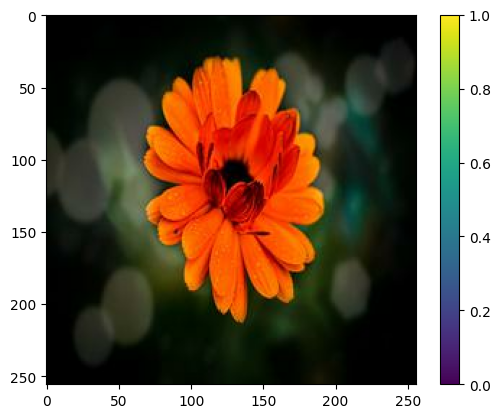

In [15]:
print(train_ds.class_names) # Validar que sí asignara bien keras las labels

first_element = list(train_ds.take(1))[0]
prueba = first_element[0][0].numpy()
prueba = prueba / 255
print(prueba.min(), prueba.max())

plt.figure()
plt.imshow(prueba)
plt.colorbar()
plt.grid(False)
plt.show()



### Escalamiento de las imagenes

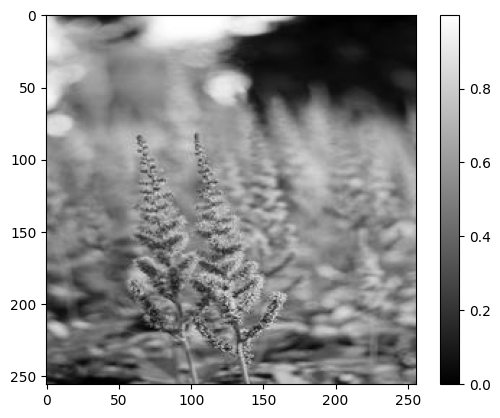

(256, 256, 1)


In [35]:
def grayscaleAndScaling(image, label):
    image = tf.cond(
        tf.reduce_max(image) > 1.0,
        lambda: image / 255.0,
        lambda: image
    )

    image = tf.cond(
        tf.equal(tf.shape(image)[-1], 3),
        lambda: tf.image.rgb_to_grayscale(image),
        lambda: image
    )

    return image, label

train_ds = train_ds.map(grayscaleAndScaling)
validation_ds = validation_ds.map(grayscaleAndScaling)
test_ds  = test_ds.map(grayscaleAndScaling)

#Evidencia
first_element = list(train_ds.take(1))[0]
prueba = first_element[0][0].numpy()
plt.figure()
plt.imshow(prueba, cmap="gray")
plt.colorbar()
plt.grid(False)
plt.show()

print(prueba.shape)
# TODO()
# Data augmentation para evitar overfitting

